In [ ]:
import os
import numpy as np
from matplotlib import pyplot

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# Calculo cientifico y vectorial para python
import numpy as np

# Librerias para graficar
from matplotlib import pyplot

# Modulo de optimización de scipy
from scipy import optimize

# le dice a matplotlib que incruste gráficos en el cuaderno
%matplotlib inline

Carga del conjunto de datos

En esta celda se carga el archivo `ijcnn1.csv` utilizando la función `np.loadtxt()`.

El parámetro `delimiter=','` indica que los datos están separados por comas, mientras que `skiprows=1` permite ignorar la primera fila del archivo.

De esta manera, los datos quedan almacenados en una matriz de NumPy para poder realizar posteriormente el procesamiento y entrenamiento del modelo.

In [ ]:
# Leer datos
data = np.loadtxt('/content/drive/MyDrive/tareas/lab3/ijcnn1.csv', delimiter=',',
                  skiprows=1)

X, y = data[:,:-1 ], data[:,0]
X.shape

(91701, 22)

División del dataset
Se divide el conjunto de datos en:
- 80% para entrenamiento (`X_train`, `y_train`)
- 20% para prueba (`X_test`, `y_test`)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)
print(f'X_Train:{X_train.shape}')
print(f'X_test:{X_test.shape}')

X_Train:(73360, 22)
X_test:(18341, 22)


Función Sigmoide

Su función es transformar un valor `z` en un resultado comprendido entre 0 y 1 este resultado puede interpretarse como una probabilidad.



In [ ]:
def sigmoid(z):
    # Calcula la sigmoide de una entrada z
    # convierte la intrada a un arreglo numpy
    z = np.array(z)

    g = np.zeros(z.shape)

    g = 1 / (1 + np.exp(-z))

    return g

Normalización de características

La normalización permite que las diferentes características tengan una escala comparable y ayuda al proceso de descenso por gradiente, ya que evita que algunas características tengan una influencia excesiva debido únicamente a su escala.

In [ ]:
def  featureNormalize(X):
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0)
    sigma = np.std(X, axis = 0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

Los datos de prueba son normalizados utilizando la media y desviación para X_train y X_test.

In [ ]:
# llama featureNormalize con los datos cargados
X_train, mu, sigma = featureNormalize(X_train)
X_test = (X_test - mu) / sigma

In [ ]:
z = [-100, 0.5, 1000000]
g = sigmoid(z)

print('g(', z, ') = ', g)

g( [-100, 0.5, 1000000] ) =  [3.72007598e-44 6.22459331e-01 1.00000000e+00]


La X matriz resultante contiene una primera columna de unos y posteriormente todas las características normalizadas.

In [ ]:
# Configurar la matriz adecuadamente, y agregar una columna de unos que corresponde al termino de intercepción.
m, n = X_train.shape
# Agraga el termino de intercepción a A
X= np.concatenate([np.ones((m, 1)), X_train], axis=1)

## Función de costo

La función de costo permite medir qué tan bien se está comportando el modelo durante el entrenamiento.

Se utiliza el costo basado en la entropía cruzada. Primero se calculan las predicciones mediante la función sigmoide y posteriormente se compara la predicción con los valores reales.

El objetivo del entrenamiento es reducir el valor del costo para obtener un modelo que realice mejores predicciones.

In [ ]:
def calcularCosto(theta, X, y):
    # Inicializar algunos valores utiles
    m = y.size  # numero de ejemplos de entrenamiento

    J = 0
    h = sigmoid(X.dot(theta.T))
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))

    return J

## Descenso por gradiente

El descenso por gradiente es el método utilizado para encontrar los valores de `theta` que permiten al modelo realizar mejores predicciones.

En cada iteración se calculan las predicciones utilizando la función sigmoide. Luego se actualizan los valores de `theta` utilizando el error entre las predicciones y los valores reales.

Este proceso se repite durante un número determinado de iteraciones con el objetivo de minimizar la función de costo.

In [ ]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        h = sigmoid(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)

        J_history.append(calcularCosto(theta, X, y))
    return theta, J_history

## Configuración de los parámetros

Para realizar el entrenamiento se establece un valor para la tasa de aprendizaje `alpha` y el número de iteraciones.

En este caso se utiliza:

- `alpha = 0.03`
- `num_iters = 1500`

La tasa de aprendizaje controla el tamaño de los pasos realizados durante la actualización de `theta`, mientras que el número de iteraciones indica cuántas veces se ejecutará el proceso de actualización.

theta calculado por el descenso por el gradiente: [-3.04456634e+00  2.12551541e+00 -2.74999902e-03 -1.45781419e-02
 -1.46727638e-02  2.66836481e-02  3.21771983e-02 -3.25438852e-02
 -4.00975632e-02  1.77555890e-02  2.98539877e-02 -2.06890092e-03
 -1.02216831e-02 -1.05483682e-04  2.85850919e-02  3.46409998e-02
  3.22298666e-02 -6.60646197e-03 -1.25422324e-01 -2.30429297e-01
 -8.65858834e-02  5.10222820e-02  6.42802840e-02]


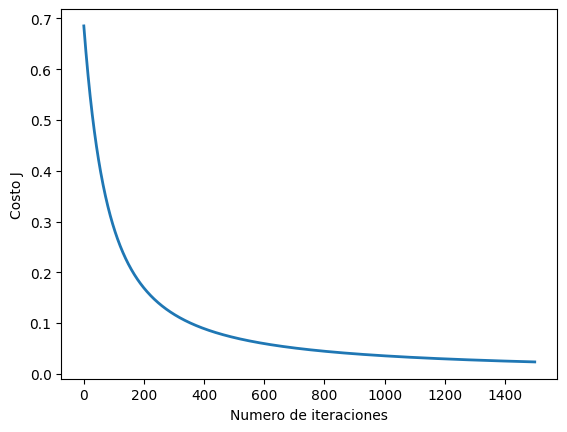

In [ ]:
# Elegir algun valor para alpha (probar varias alternativas)
alpha = 0.03
num_iters = 1500

# inicializa theta y ejecuta el descenso por el gradiente
theta = np.zeros(23)
theta, J_history = descensoGradiente(theta, X, y_train, alpha, num_iters)

# Grafica la convergencia del costo
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')

# Muestra los resultados del descenso por el gradiente
print('theta calculado por el descenso por el gradiente: {:s}'.format(str(theta)))


## Predicciones sobre los datos de entrenamiento

Después de entrenar el modelo se realizan predicciones utilizando los datos de entrenamiento.

Primero se calcula la probabilidad mediante la función sigmoide. Después se convierte esta probabilidad en una clase utilizando un umbral de 0.5.

Si la probabilidad es mayor o igual a 0.5, se asigna la clase 1. En caso contrario, se asigna la clase 0.

In [ ]:
# Predicciones sobre entrenamiento
y_pred_train = sigmoid(np.dot(X, theta))

# Convertir probabilidades a clases 0 y 1
y_clase_train = (y_pred_train >= 0.5).astype(int)

# Calcular precisión
aciertos_train = np.sum(y_clase_train == y_train)
total_train = len(y_train)
print(f"Precisión entrenamiento: {(aciertos_train/total_train)*100:.2f}%")

Precisión entrenamiento: 100.00%


## Predicciones sobre los datos de prueba

Después del entrenamiento, el modelo se utiliza con los datos de prueba.

 Luego se agrega el término de intercepción y se calculan las probabilidades mediante la función sigmoide.

Finalmente, utilizando el umbral de 0.5, se obtienen las clases predichas.

In [ ]:
X_array = np.concatenate([np.ones((X_test.shape[0], 1)), X_test], axis=1)


In [ ]:
y_predicted = sigmoid(np.dot(X_array, theta))
y_clase = (y_predicted >= 0.5).astype(int)
aciertos = np.mean(y_clase == y_test) * 100
print("Porcentaje de acierto Test: {:.2f}%".format(aciertos))


Porcentaje de acierto Test: 100.00%


## Matriz de Confusión

La matriz de confusión permite analizar con mayor detalle las clasificaciones realizadas por el modelo.

La matriz muestra la cantidad de ejemplos clasificados correctamente y los posibles errores entre las clases 0 y 1.


Matriz de Confusión:
[[16634     0]
 [    0  1707]]


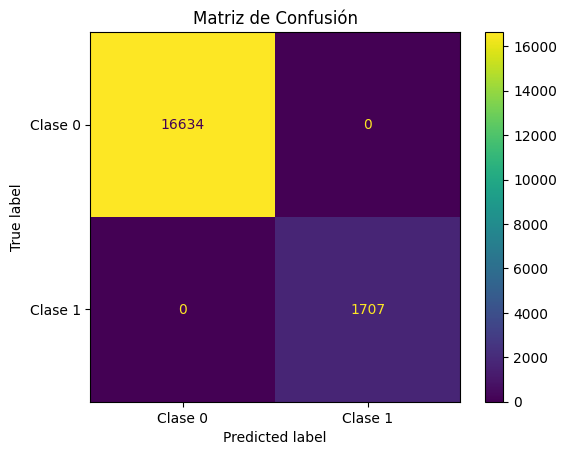

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Matriz de confusión
cm = confusion_matrix(y_test, y_clase)

print("Matriz de Confusión:")
print(cm)

# Gráfica
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Clase 0", "Clase 1"]
)

disp.plot()

plt.title("Matriz de Confusión")
plt.show()

## Conclusión

En este laboratorio se implementó un modelo de regresión logística para realizar una clasificación binaria utilizando el conjunto de datos `ijcnn1.csv`.

Durante el proceso se realizó la carga de los datos, la separación entre características y variable objetivo, la división en datos de entrenamiento y prueba, la normalización de las características y el entrenamiento mediante descenso por gradiente.

Los resultados obtenidos muestran una precisión del 100.00% tanto en los datos de entrenamiento como en los datos de prueba. Además, la matriz de confusión no presenta errores de clasificación, ya que todos los valores se encuentran correctamente clasificados en la diagonal principal.

Por lo tanto, de acuerdo con los resultados obtenidos en este laboratorio, el modelo logró clasificar correctamente los ejemplos utilizados para la evaluación.